Phys 540 project 1
<br> Andrew Koren

1. rk method. This is what we used in my comuptational physics class from my undergrad, hence the detailed commented instructions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# some code from my undergrad

def integrate_ode_rungekutta( rhs, y0:np.array, x0, xf, h, s, a, b, c, args=None):
    # set the dimension of the y vector
    nd = len(y0)
    
    # k_i storage
    kf = np.zeros( (s,nd) )
    
    # number of steps, may need one more if xf-x0 is not
    # an integer multiple of h
    nf = ( xf - x0 ) / h
    n = int(nf)

    # initialization
    xlist = [x0]
    ylist = [y0]
    status = 1
    
    y = y0.copy()

    # integration
    for step in range(n+1): #integration steps
        if step == n:
            if xlist[-1] == xf: # last step verification
                break
            else:
                h = xf - xlist[-1]

        for i in range(s): #rk steps
            yi = y + h * sum(a[i,j] * kf[j] for j in range(i))
            if args != None: 
                ki = rhs(xlist[-1]+h*c[i], yi, args)
            else: 
                ki = rhs(xlist[-1]+h*c[i], yi)
            y += h * b[i] * ki
        xlist.append(xlist[-1]+h)
        ylist.append(y.copy())

    if xlist[-1] == xf:
        status = 0   
    
    return status, y, xlist, ylist

# unfortunately no auto-step-size

Here are three butcher tableaus, one is the most common rk4 tableau, while the other two are forward/backward euler method

In [ ]:
# fourth-order Runge-Kutta method from wikipedia
# wikipidea cites:
# Süli, Endre; Mayers, David (2003)
# An Introduction to Numerical Analysis, 
# Cambridge University Press, ISBN 0-521-00794-1

s = 4
a = np.zeros( (s,s) )   # middle 
b = np.zeros( s )       # bottom
c = np.zeros( s )       # left

a[1,0] = 1/2
a[2,1] = 1/2
a[3,2] = 1
b[0] = 1/6
b[1] = 1/3
b[2] = 1/3
b[3] = 1/6
c[1] = 1/2
c[2] = 1/2
c[3] = 1

# forward Euler 
aFE = np.array([0])
bFE = np.array([1])
cFE = np.array([0])

# backward Euler 
aBE = np.array([1]) 
bBE = np.array([1])
cBE = np.array([1])

butcher_tableau = [[s,a,b,c],
                   [1,aFE,bFE,cFE],
                   [1,aBE,bBE,cBE]
                  ]
butcher_tableau

names = ['rk4', 'explicit Euler', 'implicit Euler']

We'll compare results for $y'(t)=y(t)$

In [18]:
from sympy import dsolve, Function, Eq, Derivative
from sympy.abc import t
y = Function('y')

analytical = dsolve(Eq(Derivative(y(t), t),y(t)))
display(analytical, analytical.replace(t,0))

Eq(y(t), C1*exp(t))

Eq(y(0), C1)

Visual comparison vs analytical result

Text(0, 0.5, 'y(t)')

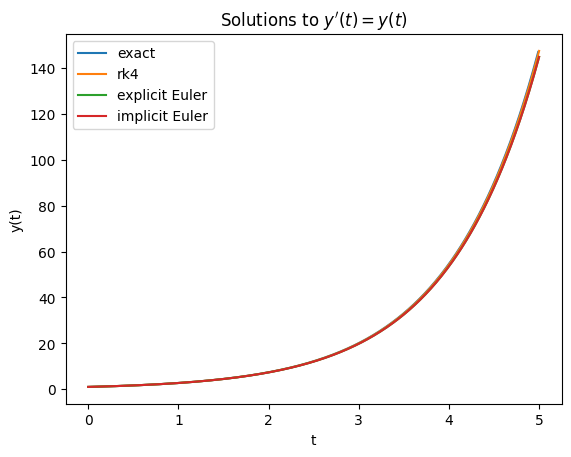

In [19]:
y0 = 1.0 # float, not int
h = 0.01 # step size
t0 = 0
tf = 5

t = np.arange(t0, tf, h)

def rhs_ode(t, y):
    return y

y_analytical = lambda y0, t: y0*np.exp(t)
plt.plot(t, y_analytical(y0, t), label='exact')


results = []
for tableau, name in zip(butcher_tableau, names):
    status, yf, xlist, ylist = integrate_ode_rungekutta(rhs_ode, np.array([y0]), t0, tf, h, *tableau)
    assert not status
    plt.plot(xlist, ylist, label=name)
    results.append([xlist, ylist, name])

plt.legend()
plt.title(r'Solutions to $y^\prime(t)=y(t)$')
plt.xlabel('t')
plt.ylabel('y(t)')

To compare each solution, let's pull up the error as a function of $t$

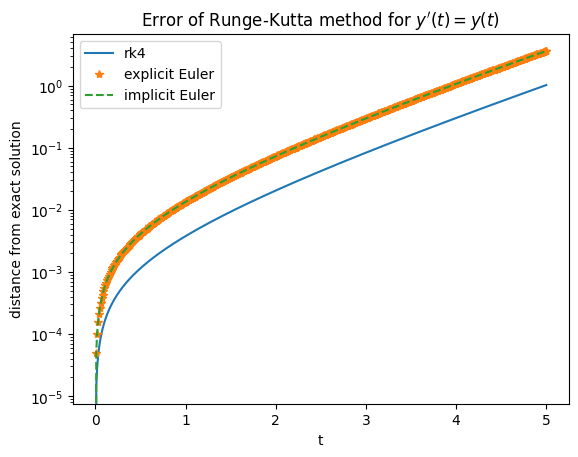

In [20]:
for i, result in enumerate(results):
    xlist, ylist, name = result
    true_y = y_analytical(y0, np.array(xlist))
    error = np.abs(true_y-np.array(ylist).flatten())

    style = ['-', '*', '--'][i]
    plt.plot(xlist, error, style, label=name)

plt.legend()
plt.yscale('log')
plt.title(r'Error of Runge-Kutta method for $y^\prime(t)=y(t)$')
plt.xlabel('t')
plt.ylabel('distance from exact solution');

All errors grow exponentially because the function grows exponentially, so I've also included relative error below. Usually $\mathcal{O}$ notation error would be done by measuring accuracy vs step size, but that's not necessary for this assignment.

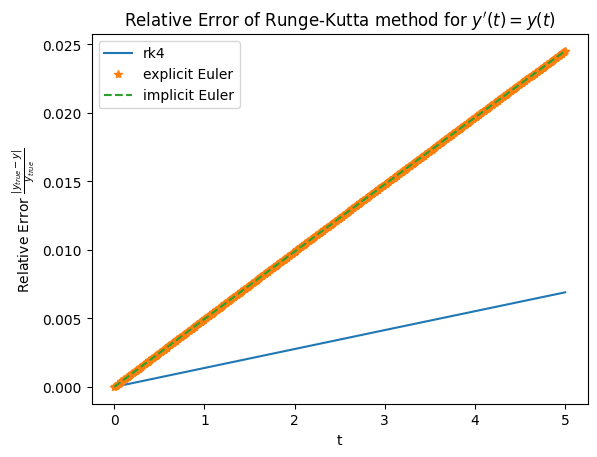

In [21]:
for i, result in enumerate(results):
    xlist, ylist, name = result
    true_y = y_analytical(y0, np.array(xlist))
    error = np.abs(true_y-np.array(ylist).flatten())/true_y

    style = ['-', '*', '--'][i]
    plt.plot(xlist, error, style, label=name)

plt.legend()
#plt.yscale('log')
plt.title(r'Relative Error of Runge-Kutta method for $y^\prime(t)=y(t)$')
plt.xlabel('t')
plt.ylabel(r'Relative Error $\frac{|y_{true}-y|}{y_{true}}$');

2. sextupole magnet.

Ampere's law: 
$$
    \oint \vec B \cdot d\vec{l} = \mu_0 I_{enc}
\\  \nabla \times B = \mu_0 J
$$
The field generated is only for the space in the middle, not the iron or coils. Following the quadrupole example, we'll follow the equipotent lines, which are at $x^2y - {1 \over 3} y^3 = c$, which looks like... uhh...

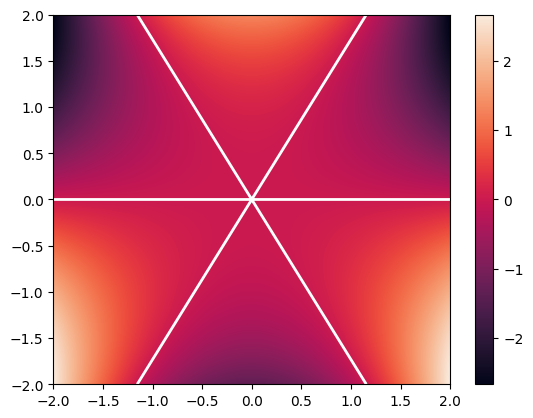

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from seaborn.cm import rocket

x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)

F = X**2 * Y - (1/3)*Y**3

fig, ax = plt.subplots()

im = ax.imshow(
    -0.5 * F,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin='lower',
    aspect='auto',
    cmap=rocket
)

c = 0.0  # x^2 y - (1/3) y^3 = c
ax.contour(X, Y, F, levels=[c], colors='white', linewidths=2)

fig.colorbar(im, ax=ax)
plt.show()

We could follow the $y=0$ line, but honestly I think the integral is simpler if we just follow the $x=0$ line

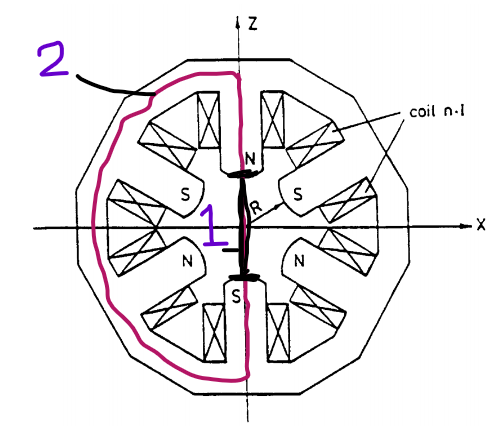

This gives us a small magnetic field $H$ on curve $2$, so we only need to do the simple integral of $B_y$ on curve $1$

$$
    \oint H \cdot dl = \int_{-R}^{R} {B_y(0,y) \over \mu_0} dy + \int_2 \underbrace{H \cdot dl}_{\text{small}} = I_{enc}
\\[0.25em]
    \int_{-R}^{R} - {1 \over 2 \mu_0}g' y^2 dy = \left.- {1 \over 6 \mu_0} g' y^3 \right|_{-R}^R
    = {1 \over 3 \mu_0} g' R^3 = I_{enc}
\\  g' = {3 \mu_0 I_{enc} \over R^3}
$$
The N and S poles enclosed by the loop have current that cancel each other, so the two poles split in half by the loop contribute $I_{enc} = 2NI$, yielding the final answer 
$$
g' = {6 \mu_0 N I \over R^3}
$$

3. Imaging optimization

In class we've covered the vast majority of how the triplet optimization works, with the vast majority already included in `tao.init` and `triplet.bmad`. The actual work was mostly setting up bmad/tao and figuring out syntax. 

I decided to plot a point off-center so we could see orbit flipping during propogation as well as the closed geometry parameters. This was configured via a `setup.tao` file rather than in a `tao.init` namelist. To plot with pgplot, we must first output to PostScript, and then use another package/program to convert to pdf. I've chosen `ps2pdf` from ghostscript:

In [ ]:
sudo apt-get install ghostscript

although I'm not quite sure how to do landscape output. The ps file was easy to make, just `write ps project1.ps`, and I've included the open and closed geometry plots below. The second plot has labels overlapping on the orbits, but orbits aren't valid for closed geometry anyways. 

Using the same lattice as provided, the optimal lattice had the strengths:

<br> FQ[K1] =  3.77815202559555141E-001
<br> DQ[K1] = -6.67866465359443162E-001

although the merit for closed-orbit was 20 orders of magnitude smaller than the off-center particle. I have not included twiss tables or transfer matricies in this pdf, but I did notice that the imaging requirement of zero angular dependence on final position is close. For the open geometry, I have

$$
    \langle x | m_x \rangle =  0.00001407
\\  \langle y | m_y \rangle = -0.00000604.
$$

